*Please update the pledges below with your name.*

I **Aurora LePort** pledge that the code and responses in this notebook are **entirely my own work.**

**Generative AI Disclosure**  
I **Aurora LePort** further pledge that:  
1. All text responses were written by me, **without** consultation of an LLM.
2. Any code that was partially/completely generated with AI help **will be disclosed** here and/or with comments near the code (e.g. `# used LLM for this cell`).


In [1]:
# Run the below command if necessary to install libraries
# pip install pandas numpy seaborn matplotlib scipy pyarrow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
import logging
from typing import Union, List, Dict, Any
logging.basicConfig(level=logging.INFO)

Sections where you should add your own code and/or analysis are <mark>highlighted</mark>. Communicating your analysis with clear discussion and plots is very much appreciated. Feel free to add additional cells for any of your analysis and discussion.

For this challenge you will be using raw 3-axis accelerometer (ACM) signals measured from a wearable device to build an automatic activity detection algorithm.

We will be using the following two data files, which represent a single session from a single individual instructed to perform various activities in a laboratory setting.

- **user1_accelerometer_data.parquet** - This pyarrow parquet file has raw accelerometer signals in x/y/z directions (in mill-g), with `time` (in seconds since epoch) continuously sampled at 50Hz.
- **user1_activity_labels.csv** - This CSV file has the `time_start`, `time_end`, and `id` of each activity performed during the session.


In [4]:
pwd

'/Users/aurora/Projects/MyGit/IndependentProjects/Oura_ml_challenge/ml_ds_challenge'

In [5]:
file_path = '/Users/aurora/Projects/MyGit/IndependentProjects/Oura_ml_challenge/ml_ds_challenge'

data1 = pd.read_parquet(f"{file_path}/user1_accelerometer_data.parquet")
data1.head(1)

,time,x_accel_mg,y_accel_mg,z_accel_mg
0,1.680644e+09,843,-204,390


In [6]:
labels1 = pd.read_csv(f"{file_path}/user1_activity_labels.csv")
labels1

,id,time_start,time_end
0,lying_down_rest_5_min,1.680644e+09,1.680645e+09
1,general_warmup_3_min,1.680645e+09,1.680645e+09
2,bike_100,1.680645e+09,1.680645e+09
3,bike_130,1.680645e+09,1.680646e+09
4,bike_160,1.680646e+09,1.680646e+09
5,sitting_recovery_post_bike_5_min,1.680646e+09,1.680646e+09
6,walking_1_6,1.680646e+09,1.680646e+09
7,walking_2_2,1.680646e+09,1.680647e+09
8,walking_2_8,1.680647e+09,1.680647e+09
9,running_5,1.680647e+09,1.680647e+09


In [7]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209200 entries, 0 to 209199
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   time        209200 non-null  float64
 1   x_accel_mg  209200 non-null  int64  
 2   y_accel_mg  209200 non-null  int64  
 3   z_accel_mg  209200 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 6.4 MB


In [8]:
labels1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          13 non-null     object 
 1   time_start  13 non-null     float64
 2   time_end    13 non-null     float64
dtypes: float64(2), object(1)
memory usage: 444.0+ bytes


As you can see above, the labels fall into 5 larger categories:
- `rest`/`recovery` = periods of relative inactivity
- `bike` = at three different intensities
- `run` = at three different intensities
- `walk` = at three different intensities
- `other` = unspecified warmup activity (can ignore for this challenge)

# Problem 1 - Data Wrangling and EDA

Let's do some exploratory data analysis, but first you will need to wrangle the data a little bit.

## <mark>Merge data and labels</mark>

Create a function that will use the start and end times of each activity to label each individual timestamp of the accelerometer data by `id`. 

In [ ]:
# This function is limited to data and labels with hard coded column names. This could be updated to accept dynamic column names.

def merge_data(data, labels):
    """Merge 50hz accelerometer data with activity labels
    and discard time points with no label.
    
    Inputs:
          data - DataFrame of raw accelerometer values sampled @ 50Hz
          labels - DataFrame of activity labels with start and end time
      
    Output:
          DataFrame of raw accelerometer values sampled @ 50Hz.
    """
    
    # sort the data
    data.sort_values('time', inplace=True)
    labels.sort_values('time_start', inplace=True)

    logging.info("Data and labels sorted by time.")
    
    ### used LLM for this: I knew of pd.merge_asof, but consulted Gemini for proper syntax ###
    # Merge based on 'time' between start time and end time
    merged_df = pd.merge_asof(data, labels, left_on='time', right_on='time_start', direction='forward')

    logging.info(f"Data merged based on time between start time and end time. size merged data: {merged_df.shape} vs size of data: {data.shape}")
    
    # Filter results to only keep matches where time < time_end
    merged_df = merged_df[merged_df['time'] < merged_df['time_end']]
    logging.info(f"Filtered merged data to keep only matches where time < time_end. size filtered data: {merged_df.shape}")
    
    return merged_df

In [23]:
# Tests should be written to ensure the size of the original data and merged data are the same, ensuring merging labels does not inflate original data size. 

def test_merge_data():
    # Create sample data
    data = pd.DataFrame({
        'time': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:01', '2023-01-01 10:00:02']),
        'x_accel_mg': [100, 150, 200],
        'y_accel_mg': [110, 160, 210],
        'z_accel_mg': [120, 170, 220]
    })

    labels = pd.DataFrame({
        'time_start': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:02']),
        'time_end': pd.to_datetime(['2023-01-01 10:00:01', '2023-01-01 10:00:03']),
        'activity': ['Run', 'Walk']
    })

    merged = merge_data(data, labels)
    
    assert merged.shape[0] == 3, "Merged data should have 3 rows"
    assert 'activity' in merged.columns, "Merged data should contain activity column"
    assert merged.iloc[0]['activity'] == 'Run', "First row activity should be Run"
    assert merged.iloc[1]['activity'] == 'Walk', "Second row activity should be Walk"
    assert merged.iloc[2]['activity'] == 'Walk', "Third row activity should be Walk"
    
    logging.info("All tests passed for merge_data function.")

In [24]:
test_merge_data()

INFO:root:Data and labels sorted by time.
INFO:root:Data merged based on time between start time and end time. size merged data: (3, 7) vs size of data: (3, 4)
INFO:root:Filtered merged data to keep only matches where time < time_end. size filtered data: (3, 7)
INFO:root:All tests passed for merge_data function.


In [25]:
merged1 = merge_data(data1, labels1)
merged1.head()

INFO:root:Data and labels sorted by time.


INFO:root:Data merged based on time between start time and end time. size merged data: (209200, 7) vs size of data: (209200, 4)
INFO:root:Filtered merged data to keep only matches where time < time_end. size filtered data: (190261, 7)


,time,x_accel_mg,y_accel_mg,z_accel_mg,id,time_start,time_end
0,1.680644e+09,843,-204,390,lying_down_rest_5_min,1.680644e+09,1.680645e+09
1,1.680644e+09,859,-172,449,lying_down_rest_5_min,1.680644e+09,1.680645e+09
2,1.680644e+09,843,-188,449,lying_down_rest_5_min,1.680644e+09,1.680645e+09
3,1.680644e+09,843,-188,425,lying_down_rest_5_min,1.680644e+09,1.680645e+09
4,1.680644e+09,875,-188,433,lying_down_rest_5_min,1.680644e+09,1.680645e+09


## <mark>Create 10-sec snippets</mark>

For now let's assume we want to analyze the accelerometer every 10 seconds. 

Let's add two columns to the `merged1` dataframe, that will enable further analysis:
- `time_window` = indicates which 10sec time bucket the sample belongs to
- `activity` = indicates which of the 5 main activity categories the sample belongs to (rest, bike, run, walk, other)

In [ ]:
### used LLM for to create the time window bucket: I prompted it by asking what the most efficient way to create a 10-second time_window bucket from epoch seconds in pandas is. 
# I then had the LLM explain exactly how np.floor(merged1['time'] / WINDOW_SIZE) * WINDOW_SIZE works, for my own understanding. 
# I created the code for the activity groups myself

def add_indicator_variables(merged, window_sec=10):
    """Add `time_window` and `activity` indicator columns to DataFrame.
    
    Inputs:
        merged - DataFrame of accelerometer with `time` and specific activity
            `id` columns
        window_sec - Time window in seconds (default = 10).
        
    Output:
          DataFrame with `time_window` and `activity` columns added.
    """
    # Calculate start epoch time of 10 sec window
    merged['window_start_epoch'] = np.floor(merged['time'] / window_sec) * window_sec
    # Convert window's start epoch time back to datetime
    merged['time_window'] = pd.to_datetime(merged['window_start_epoch'], unit='s')
    # Drop intermediate epoch column
    merged.drop(columns=['window_start_epoch'], inplace=True)

    # Create Activity group
    conditions = [
    merged['id'].str.contains('rest', case=False, na=False) |
    merged['id'].str.contains('recovery', case=False, na=False),
    # these will only run if they are not flagged as rest/recovery
    merged['id'].str.contains('bike', case=False, na=False),
    merged['id'].str.contains('run', case=False, na=False),
    merged['id'].str.contains('walk', case=False, na=False),
    ]

    choices = [
    'rest/recovery',
    'bike',
    'run',
    'walk',
    ]

    merged['activity'] = np.select(condlist=conditions, choicelist=choices, default='other')

    return merged


In [40]:
final1 = add_indicator_variables(merged1)

In [ ]:
def test_add_indicator_variables():
    """Simple test to confirm add_indicator_variables function creates time_window and activity columns correctly."""
    # Create sample merged data
    merged = pd.DataFrame({
        'time': [1680643679.091, 1680644871.371],
        'id': ['lying_down_rest_5_min', 'bike_100'],
        'x_accel_mg': [843, -266],
        'y_accel_mg': [-204, 593],
        'z_accel_mg': [390, 351],
    })

    result = add_indicator_variables(merged)
    
    assert 'time_window' in result.columns, "Result should contain time_window column"
    assert 'activity' in result.columns, "Result should contain activity column"
    assert result.iloc[0]['time_window'] == pd.to_datetime('2023-04-04 21:27:50'), "First row time_window should be 21:27:50"
    assert result.iloc[1]['time_window'] == pd.to_datetime('2023-04-04 21:47:50'), "Second row time_window should be 21:47:50"
    assert result.iloc[0]['activity'] == 'rest/recovery', "First row activity should be rest/recovery"
    assert result.iloc[1]['activity'] == 'bike', "Second row activity should be bike"
    
    logging.info("All tests passed for add_indicator_variables function.")



In [45]:
test_add_indicator_variables()

INFO:root:All tests passed for add_indicator_variables function.


In [ ]:
# I am moving on, but additional test ideas are below:

In [ ]:
# test should be written that confirm correct categories are output for all activity ids
print(final1[final1['activity'].isin(['rest/recovery'])]['id'].unique())
print(final1[final1['activity'].isin(['bike'])]['id'].unique())
print(final1[final1['activity'].isin(['walk'])]['id'].unique())
print(final1[final1['activity'].isin(['run'])]['id'].unique())
print(final1[final1['activity'].isin(['other'])]['id'].unique())

['lying_down_rest_5_min' 'sitting_recovery_post_bike_5_min'
 'sitting_recovery_post_run_5_min']
['bike_100' 'bike_130' 'bike_160']
['walking_1_6' 'walking_2_2' 'walking_2_8']
['running_5' 'running_5_6' 'running_6_2']
['general_warmup_3_min']


In [292]:
# test should be written to confirm that activity count per activity is correct
final1.groupby(['activity']).agg(activity_count=('activity', 'count'))

,activity_count
activity,
bike,37600
other,28524
rest/recovery,46451
run,36393
walk,41293


In [293]:
# test should be written to confirm that number of unique time windows per activity is correct
final1.groupby(['activity']).agg(len_time_window=('time_window', 'nunique'))

,len_time_window
activity,
bike,76
other,58
rest/recovery,96
run,74
walk,84


Plot a few 10 second snippets per category, to get a sense of what the data looks like. Briefly discuss anything notable you observe.

In [48]:
# used LLM for this cell: I knew I wanted to plot acceleration data dynamically using window indexes by activity category, 
# but consulted Gemini for best practices on plotting multiple time series subplots with proper formatting and saving the figure.

def plot_activity_data(df, window_index=0):
    plot_data = {}
    for activity in ['run', 'walk', 'bike', 'rest/recovery']:
        snippet, start_time = _get_snippet(df, activity, window_index=window_index)
        if snippet is not None:
            plot_data[activity] = snippet

    if not plot_data:
        logging.info("Could not generate representative data for plotting.")
    else:
        fig, axes = plt.subplots(len(plot_data), 1, figsize=(12, 12), sharex=False)
        fig.suptitle('10-Second Acceleration Snippets by Activity Category', fontsize=16, y=1.02)
        
        for i, (activity, snippet) in enumerate(plot_data.items()):
            ax = axes[i]
            
            # Plot the three axes
            ax.plot(snippet['timestamp'], snippet['x_accel_mg'], label='X-Axis', alpha=0.7, linewidth=1.5)
            ax.plot(snippet['timestamp'], snippet['y_accel_mg'], label='Y-Axis', alpha=0.7, linewidth=1.5)
            ax.plot(snippet['timestamp'], snippet['z_accel_mg'], label='Z-Axis', alpha=0.7, linewidth=1.5)
            
            # Formatting
            ax.set_title(f'Activity: {activity.title()}')
            ax.set_ylabel('Acceleration (mg)')
            ax.legend(loc='upper right')
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            
            # Format X-axis for better readability of time
            ax.tick_params(axis='x', rotation=45)
            
        # Adjust layout to prevent overlap
        plt.tight_layout()
        
        # Save the plot
        plt.savefig('activity_snippets_plot.png')
        logging.info("activity_snippets_plot.png")

def _get_snippet(df, activity_name, window_index=0):
    """Selects the first 10-second window for a given activity."""
    activity_df = df[df['activity'] == activity_name]
    
    # Get the unique window start times and sort them
    unique_windows = np.sort(activity_df['time_window'].unique())
    
    if window_index >= len(unique_windows):
        logging.warning(f"Window index {window_index} is too large for activity {activity_name}. Using index 0 instead.")
        window_index = 0
    
    # Select the specified window start time
    start_time = unique_windows[window_index]
    
    # Filter for the 10-second snippet
    snippet = activity_df[activity_df['time_window'] == start_time].copy()
    
    # Convert epoch time to datetime for x-axis labels (for visual clarity)
    snippet['timestamp'] = pd.to_datetime(snippet['time'], unit='s')
    
    return snippet, start_time

In [ ]:
## CONCLUSIONS ON PLOTTING 10 SECOND WINDOWS PER CATEGORY ##
# I choose windows from various start points to see how the accelerometer data varies as the activity progresses in time.
# Noise is seen in all categories across windows, but especially in walk where periods of no variability are observed. Rest/recovery also shows variability, but 
# this is expected due to the grouping of both rest and recovery activities into one category. A robust model should be able to handle variability in rest, especially
# given the distinct differences seen in run and bike activities.
# a DATA CLEANING STRATEGY is suggested towards the end of this notebook, but this seemed outside of the scope of the original ask so I simply describe it below.

INFO:root:activity_snippets_plot.png


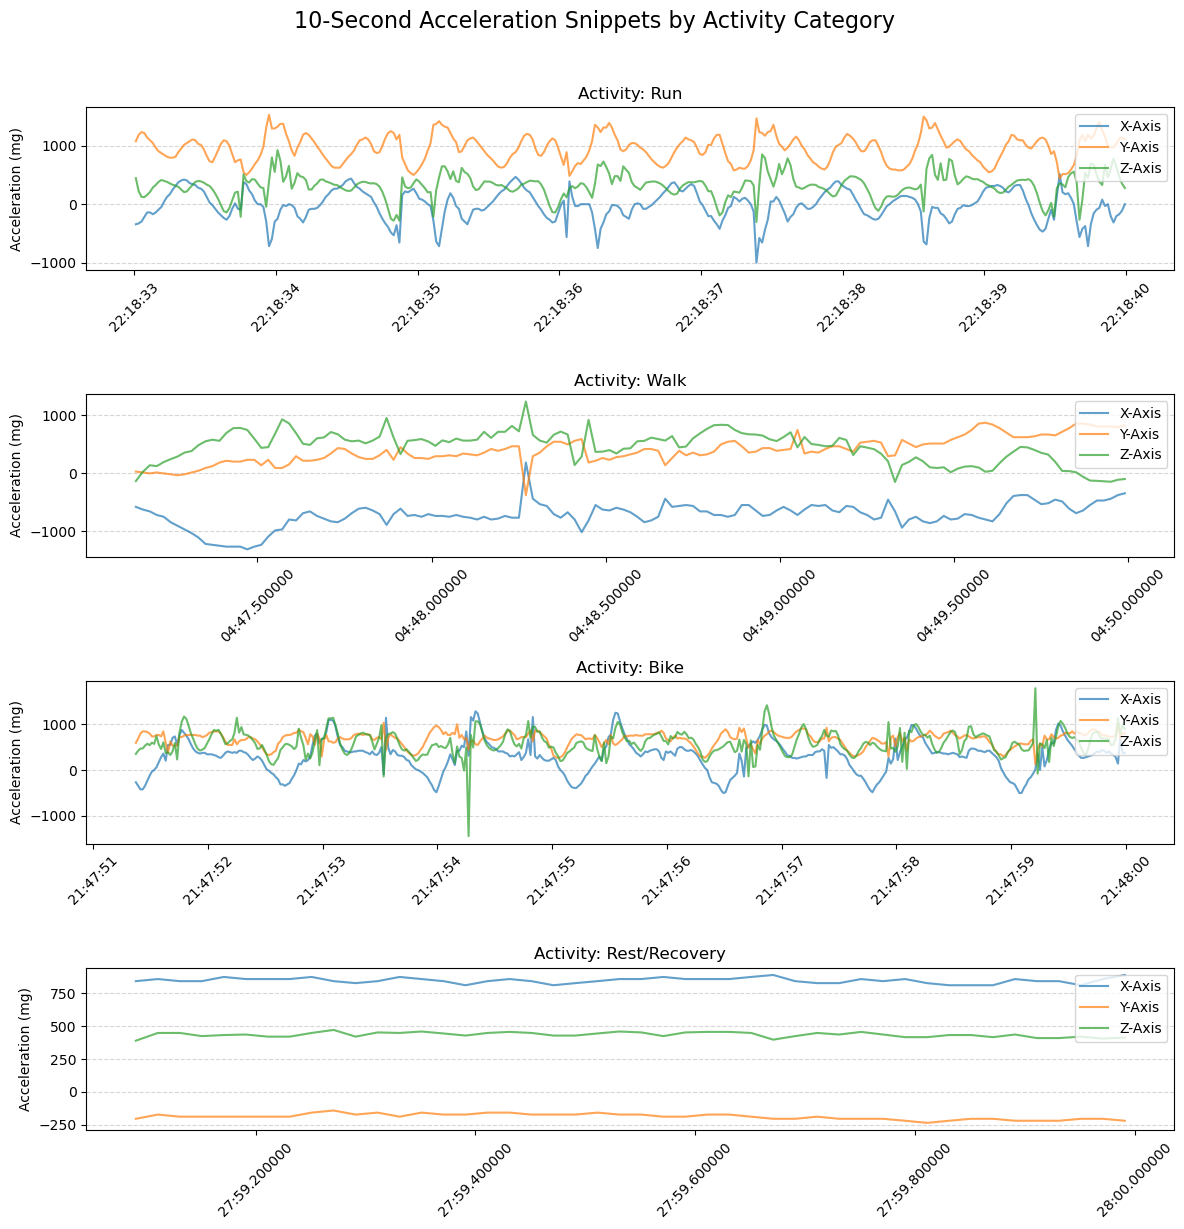

In [ ]:
# Plotting the first 10 second window (window_index=0) per activity

# Overview:  The first window is prone to carrying noise as it can capture the transition between activities leading to unusual noise or instability.
# NOTE: There is an error in the graph where walk and rest are not displaying properly. The X axis time labels should start with 21.

# run: High amplitude, high frequency. Signal shows large, fast fluctuations across all 3 axes. Peaks and troughs are prominent. 
#   The distinct periodic nature reflects the gait cycle. Magnitude is highest mong all groups. Clean recording.
# walk: Medium amplitude waves across all 3 axes. Large sharp peak around 4:48.2 likely captures a transistion or start of walk.
# bike: Plot shows a sinusodial movement that is regular and periodic, with moderate amplitude. Likely captures pedaling motion.
# rest: All three axes are flat. Definitive period of complete stillness.

plot_activity_data(final1, window_index=0)

INFO:root:activity_snippets_plot.png


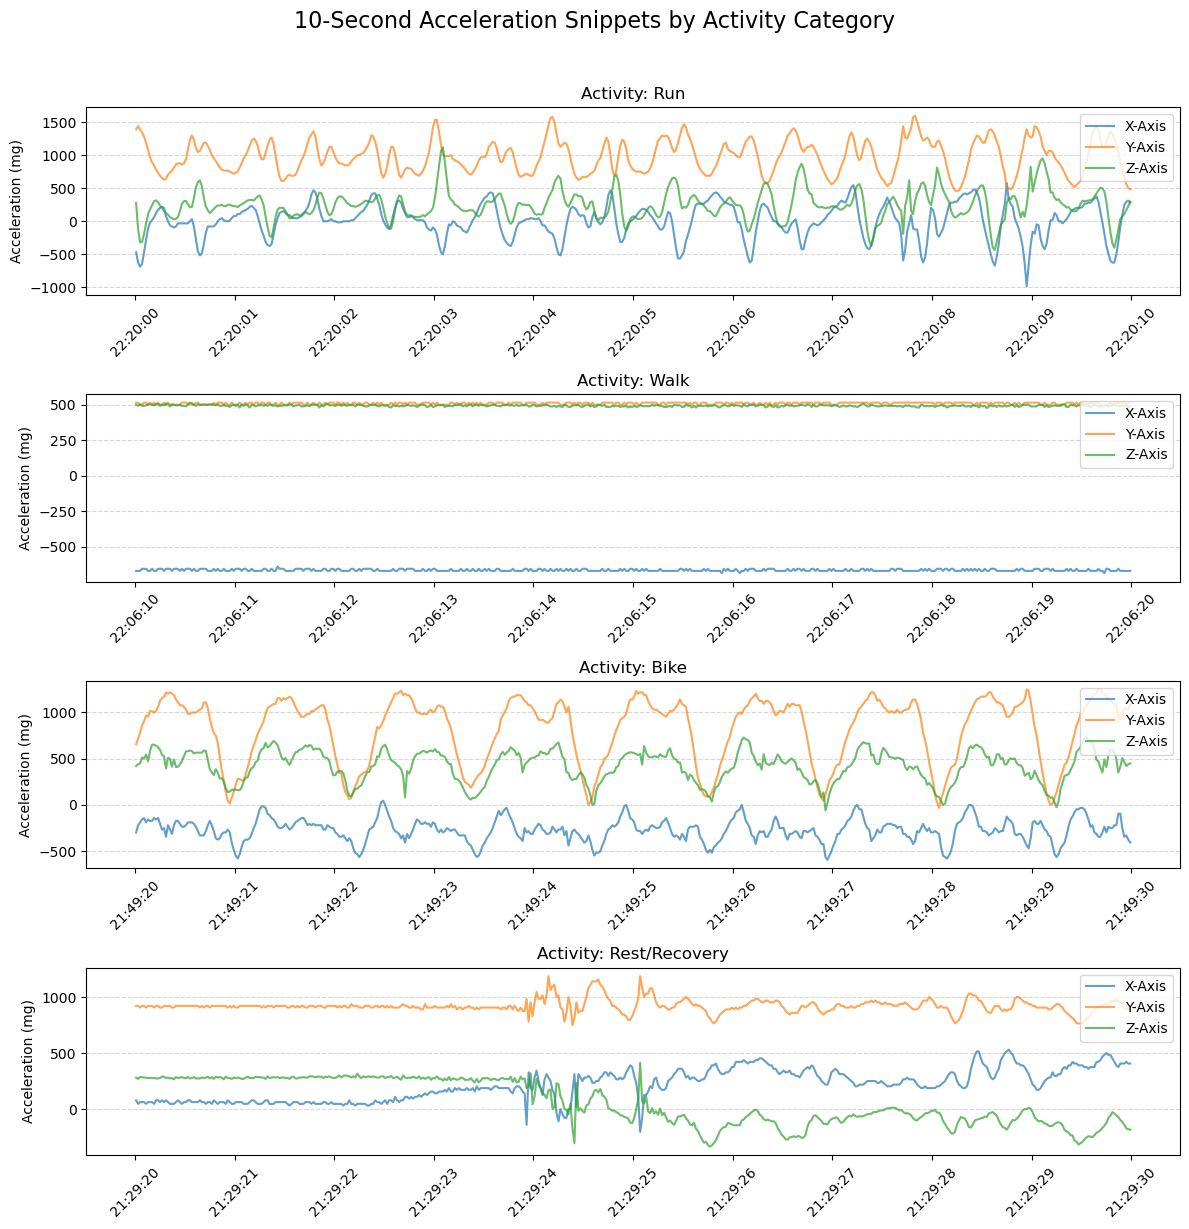

In [ ]:
# Plotting the 10th 10 second window (window_index=9) per activity

# Overview: Run and bike are clean as seen by their cyclical nature, but walk is noisy showing no variability when variability is expected.

# run/bike: This window carries less noise as compared to the first window as seen by the highly regular and more cylical nature of the run and bike activities. 
# walk: The plot is essentially flat, which could represent period of complete stillness and a labeling error!
# rest: Signal starts flat, but shows significant period of disturbance. This could be an example of transition or micro-movement during rest.
# The variability means that Features like std or peak to peak range will be elevated for this rest window period compared to a rest window of pure stillness.

plot_activity_data(final1, window_index=9)

INFO:root:activity_snippets_plot.png


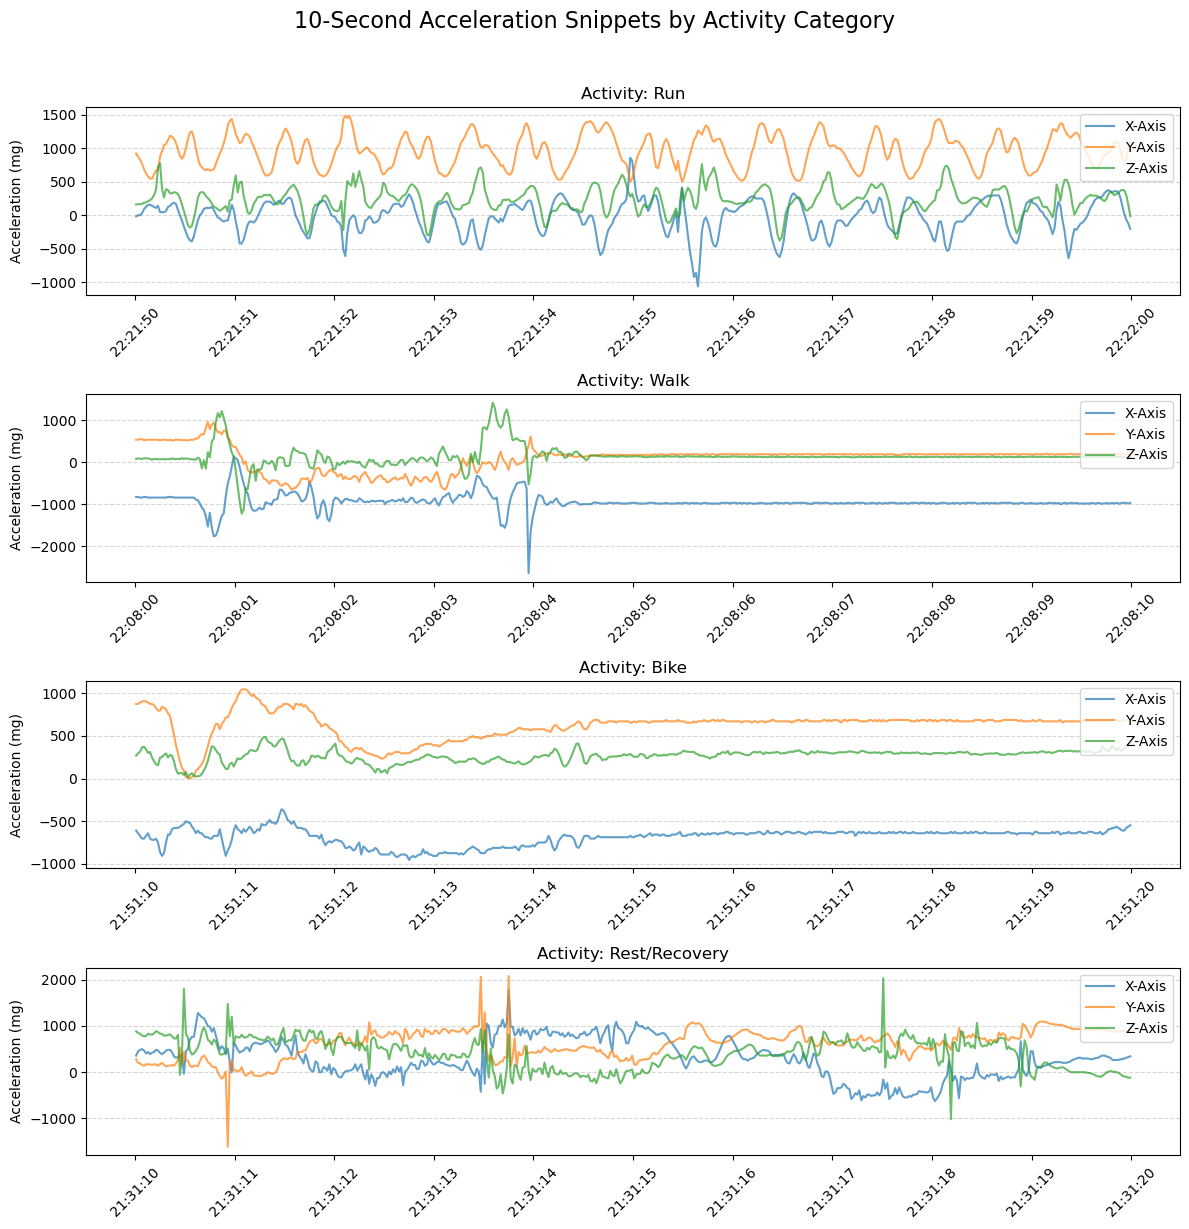

In [ ]:
# Plotting the 21st 10 second window (window_index=20) per activity

# Overview: This is a high-value sample because it should capture the activities well into their steady-state phase, far from transitional noise or instability. 
# Data cleaning is warrented to remove stillness and transition noise, especially from walk.

# run: Data is high quality
# walk: data is systematically unreliable due to prevalent stillness/transition noise within the labeled segments
# bike: Data contains significant transition and potential stillness segements; only a few intermediate windows might represent steady-state pedaling.
# rest: Data is systematically contaminated with general high acitivity movement. 

plot_activity_data(final1, window_index=20)

INFO:root:activity_snippets_plot.png


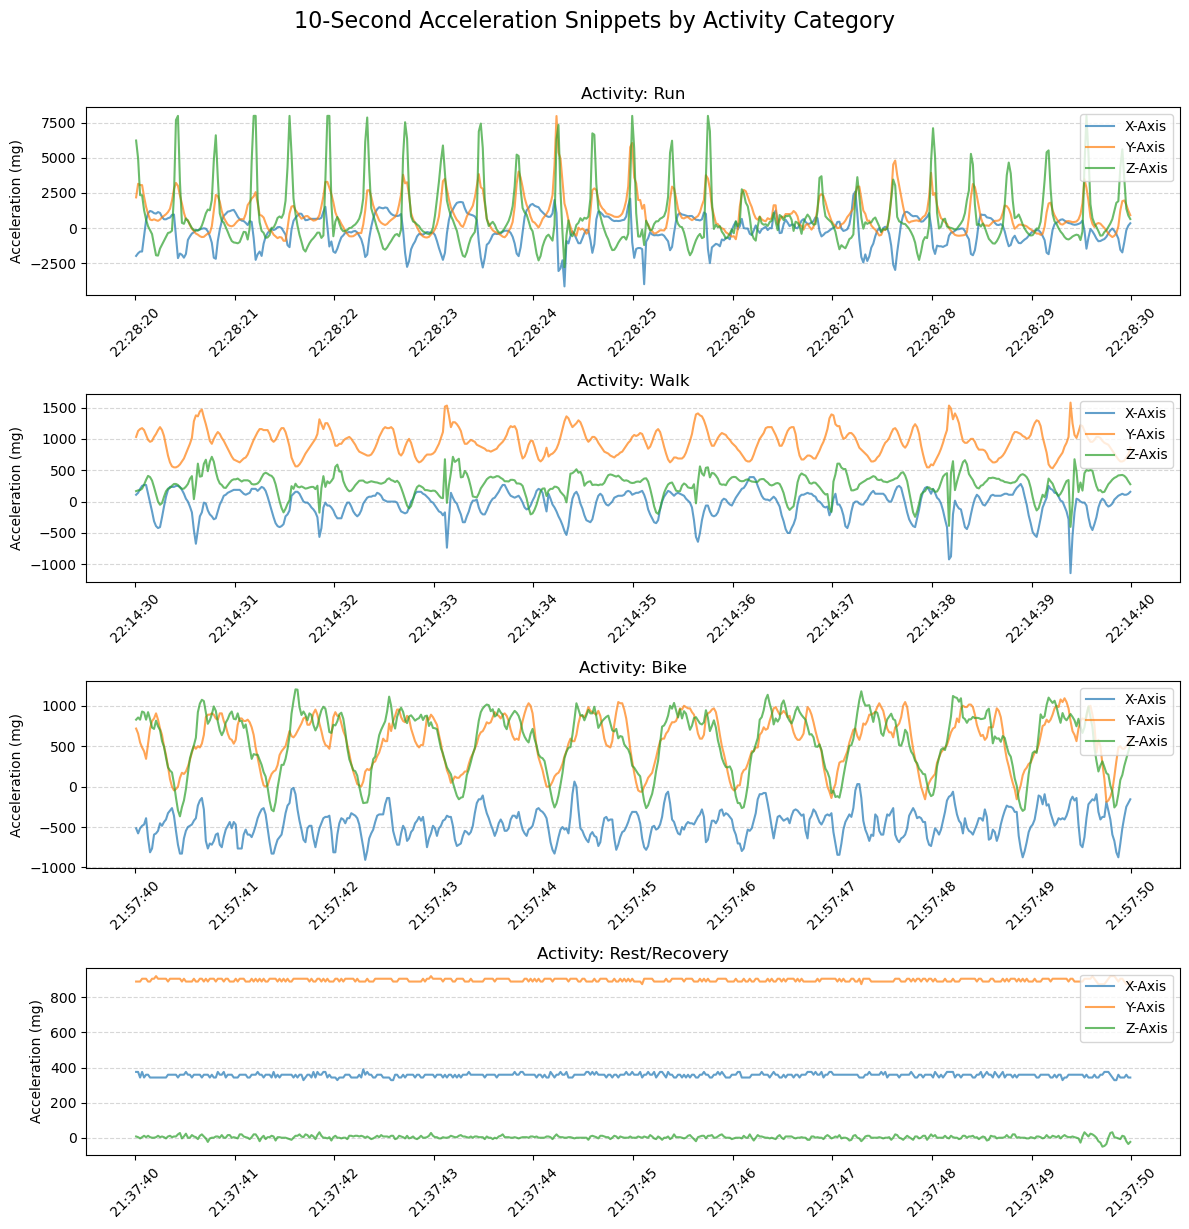

In [ ]:
# Plotting the 60th 10 second window (window_index=59) per activity

# Overview: As we move deeper into the dataset, the data quality appears to improve for the periodic activities, and the issues with noise become more localized.
# This could suggest that discarding the first several 10s windows is warrented.

# run: Pattern is highly periodic and high-amplitude, an excellent example of steady-state running that is breifly interrupted.
# walk: Captures the steady-state walking gait. The signal is clearly periodic and sinusoidal.
# bike: Highly regular, sinusoidal oscillations representing a constant pedaling speed.
# rest: The lines are almost perfectly flat and stable, represeting pure stillness.

plot_activity_data(final1, window_index=59)

## <mark>Standard deviations per activity</mark>

Let's start to compare the activities. Compute the standard deviation of each 10-second sample across each axis, and generate a plot. 

Please provide a discussion of your analysis, in the context of our final goal of building an automatic activity recognition algorithm.

In [51]:
std_features = final1.groupby(['activity','time_window']).agg(std_x=('x_accel_mg', 'std'),
                                 std_y=('y_accel_mg', 'std'),
                                 std_z=('z_accel_mg', 'std')
                                 )

std_features.reset_index(inplace=True)

std_features_melt = std_features.melt(
    id_vars=['time_window', 'activity'], 
    value_vars=['std_x', 'std_y', 'std_z'],
    var_name='Axis',
    value_name='Standard Deviation in mg'
)

std_features_melt

,time_window,activity,Axis,Standard Deviation in mg
0,2023-04-04 21:47:50,bike,std_x,357.532054
1,2023-04-04 21:48:00,bike,std_x,217.317208
2,2023-04-04 21:48:10,bike,std_x,155.772254
3,2023-04-04 21:48:20,bike,std_x,280.952431
4,2023-04-04 21:48:30,bike,std_x,198.841491
...,...,...,...,...
1159,2023-04-04 22:17:50,walk,std_z,158.089600
1160,2023-04-04 22:18:00,walk,std_z,184.230586
1161,2023-04-04 22:18:10,walk,std_z,199.218337
1162,2023-04-04 22:18:20,walk,std_z,282.172776


In [52]:
# used LLM for this cell: I knew the type of graph I wanted to plot and organized the data so that it could be plotted (see std_features above). Once I had the code organized,
# I shared a snip of it with Gemini and instructed it to create the code for a lineplot plot. I organized the code into a function myself.


# This is a utility function and can be used to plot any feature over time per activity
def plot_activity_timeseries(plot_df, 
                             y_feature:str, 
                             y_axis_label: str = '', 
                             title: str = '', 
                             savefig_name: str = 'timeseries_plot.png',
                             hue:str = None
                             ):
    # Use seaborn for a clean multi-line plot, split by activity

    facet_kwargs = {
        'row': 'activity', 
        'height': 2.5, 
        'aspect': 4, 
        'sharey': False, 
        'row_order': ['rest/recovery', 'other', 'bike', 'walk', 'run']
    }

    if hue:
        facet_kwargs['hue'] = hue

    g = sns.FacetGrid(
        plot_df, 
        **facet_kwargs
    )

    g.map_dataframe(
        sns.lineplot, 
        x='time_window', 
        y=y_feature, 
        linewidth=2
    )

    if hue:
        g.add_legend(title=hue)

    g.set_axis_labels('Time Window', f'{y_axis_label}')
    g.set_titles(row_template='Activity: {row_name}')
    g.figure.suptitle(f'{title}', fontsize=16, y=1.02)
    g.fig.tight_layout()

    # Save the plot
    g.fig.savefig(f'{savefig_name}')
    logging.info(f"{savefig_name}")

In [53]:
# The three orthogonal axes in a 3D coordinate system define the direction of the measured acceleration:

# X-Axis (Blue): Typically represents side-to-side (lateral) movement.

# Y-Axis (Orange): Typically represents up-and-down (vertical) movement.

# Z-Axis (Green): Typically represents forward-and-back (anterior-posterior) movement.

# Together, these three components capture the full magnitude and direction of motion.

INFO:root:std_dev_over_time_by_axis_plot.png


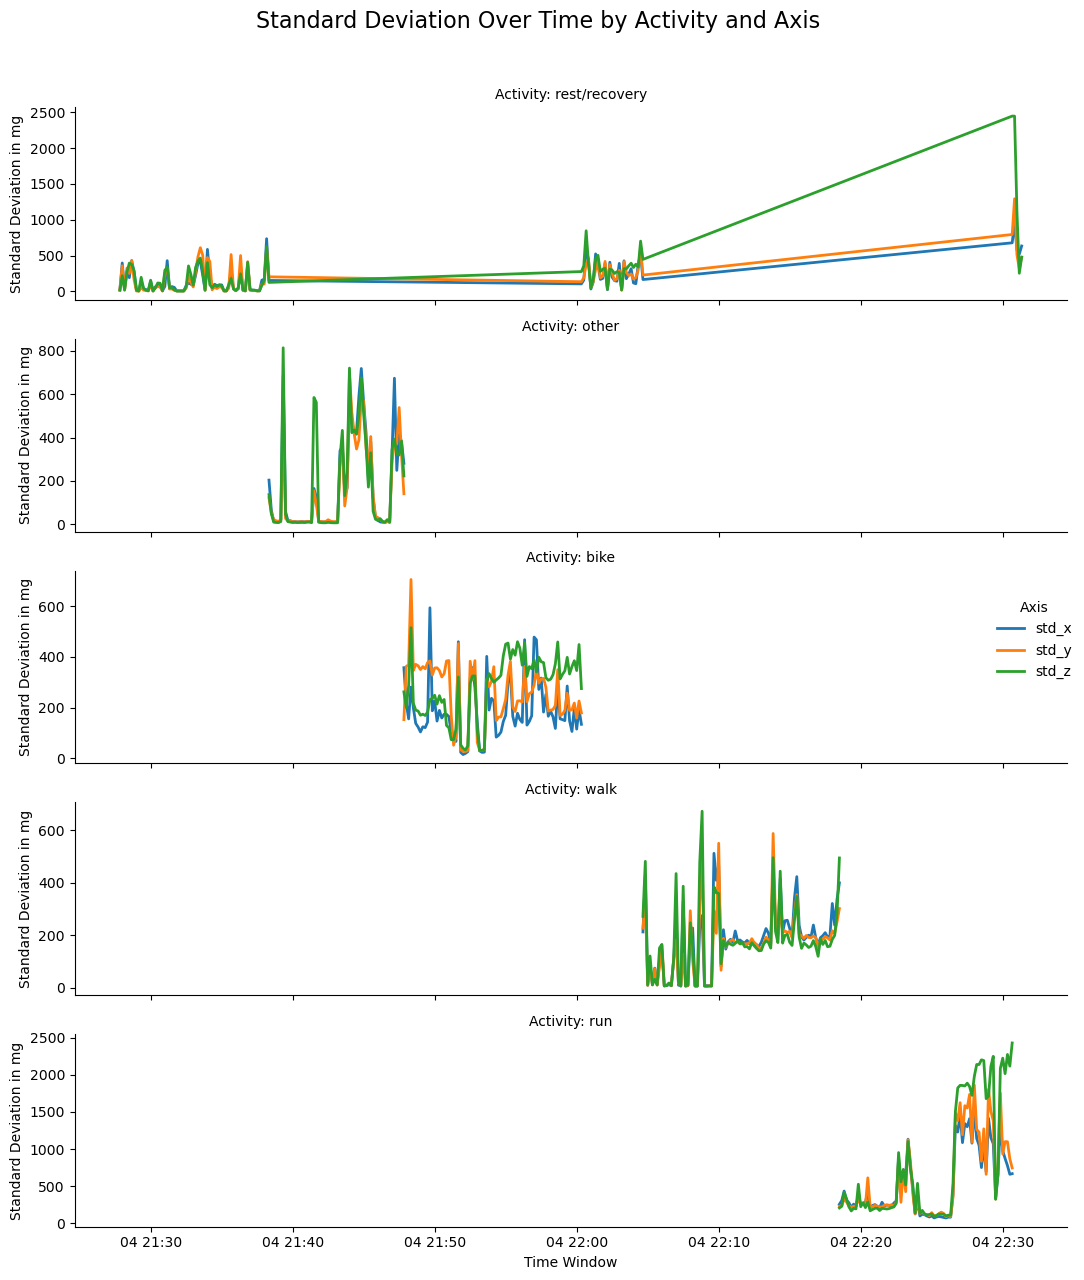

In [54]:

## CONCLUSIONS ON STD FEATURE ##
# Since the goal is to build an automatic activity recognition algorithm, I chose this view to see if the use of STD of each 10s across each axis could provide 
# discriminative power to separate the activity groups. 
# The plot confirms high discriminative power with running having the highest variability, followed by biking and walking (still in their own distinct bands), then rest.
# This indicates that a basic machine learning classifier, like a decision tree, ensemble or SVM could use std to distingish between the groups with high accuracy.

# Importantly the graph can also be used for data cleaning through its ability to point out labeling errors and transition periods.
# walk: shows a wide range of variability across all axes, with periods of low (down to 0 mg std around 22:05) and high mg std. 
#   0 mg segments indicate periods of stillness, which is indicative of mislabeling and could indicate rest in between periods of walking.
# rest: In the first time window, periods of near stillness interspersed with periods of higher variability are seen. This is indicative of the combination of 
# different categories of rest (i.e. lying down vs. recovery post activity). This variability means that features like standard deviation or peak-to-peak range will be 
# slightly higher for recovery windows vs windows of pure stillness. A robust model should be able to handle this.
# run: The lower variability around 22:20 compared to the 22:30 mark warrents investigation. It could represent a change in running pace or intensity, or a labeling error.

plot_activity_timeseries(std_features_melt,
                       y_feature='Standard Deviation in mg',
                       y_axis_label='Standard Deviation in mg', 
                       title='Standard Deviation Over Time by Activity and Axis', 
                       savefig_name='std_dev_over_time_by_axis_plot.png',
                       hue='Axis'
                       )

# NOTE: Rest has 3 distinct time windows at ~21:30, 22:00, 22:30. The graph shows lines connecting them, which is a mistake in the visual as they are not continuous time windows.
# I should clean this up!

# Problem 2 - Deeper analysis / feature engineering

## <mark>Create 1-3 features</mark>

Take this space to explore from 1 to at most 3 ideas for how to better visually separate the activities. You can use any methods or libraries (feature engineering, unsupervised learning, signal processing, etc) you are comfortable with or that you think would be helpful for this problem. However, do NOT attempt to build a supervised learning algorithm here -- later we will discuss potential solutions for that approach in Problem 3.

Please write your code for each idea as a function that can be easily re-used, e.g. on a second participant.

Please provide some plots and discussion of each of your 1-3 ideas -- why you chose it, how useful it appears to be, etc. It is okay if they underperformed compared to your initial expectation, if that is the case, discuss why. 

In [55]:
# Singal Magnitude Area (SMA) 

# SMA represents the total intensity (force/energy exerted) of movement per 10 sec time window. 
# This can be used to distingish high-intensity (Run) from low-intensity (Bike).
# STD, measures the scatter or change in the signal. 
# This can be used to distinguish high-impact motion (Run/Walk) from smooth motion (Bike).
# SMA could provide a strong complementary feature to the STD features analyzed above, as it captures different physical aspects of movement.

## CONCLUSION SMA AND CORRELATION TO STD ##
# There is high correlation between SMA and STD for running activity, which is expected as running involves high energy and high variability movements.
# But, the moderate correlation for biking indicates that while there is some relationship between total energy and variability, they are not as tightly linked 
# due to the smooth nature of cycling.
# Correlation to walking is low, but this could be indicative of the messyness of the feature.
# Ultimately, the results confirm that SMA and STD are potentially complementary features and worth including in the model. 
# I can always remove post modeling if metrics, feature and/or permuation importance are low.

# Calculate the sum of absolute values for each sample
final1['abs_sum'] = final1[['x_accel_mg', 'y_accel_mg', 'z_accel_mg']].abs().sum(axis=1)

# SMA is the mean of this sum over the window
sma_features = final1.groupby(['activity', 'time_window']).agg(sma_mg=('abs_sum', 'mean')).reset_index()
sma_features

,activity,time_window,sma_mg
0,bike,2023-04-04 21:47:50,1672.370370
1,bike,2023-04-04 21:48:00,1575.406000
2,bike,2023-04-04 21:48:10,1604.600000
3,bike,2023-04-04 21:48:20,1645.448000
4,bike,2023-04-04 21:48:30,1529.178000
...,...,...,...
383,walk,2023-04-04 22:17:50,1379.996000
384,walk,2023-04-04 22:18:00,1409.080000
385,walk,2023-04-04 22:18:10,1389.316000
386,walk,2023-04-04 22:18:20,1438.866000


INFO:root:sma_over_time_plot.png


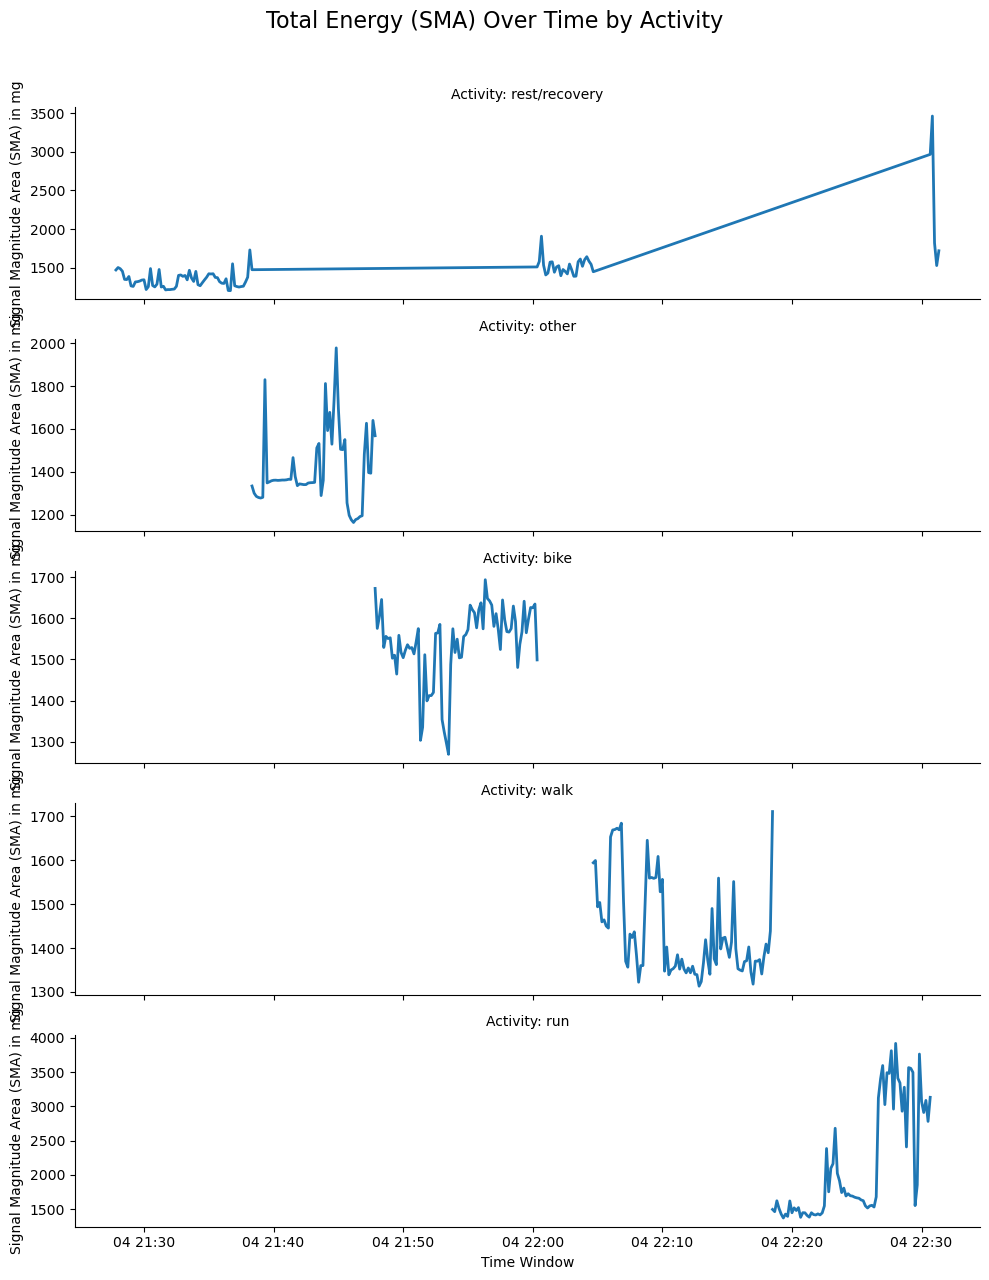

In [56]:
plot_activity_timeseries(sma_features,
                       y_feature='sma_mg',
                       y_axis_label='Signal Magnitude Area (SMA) in mg', 
                       title='Total Energy (SMA) Over Time by Activity', 
                       savefig_name='sma_over_time_plot.png',
                       )

sma_std_correlation_heatmap.png


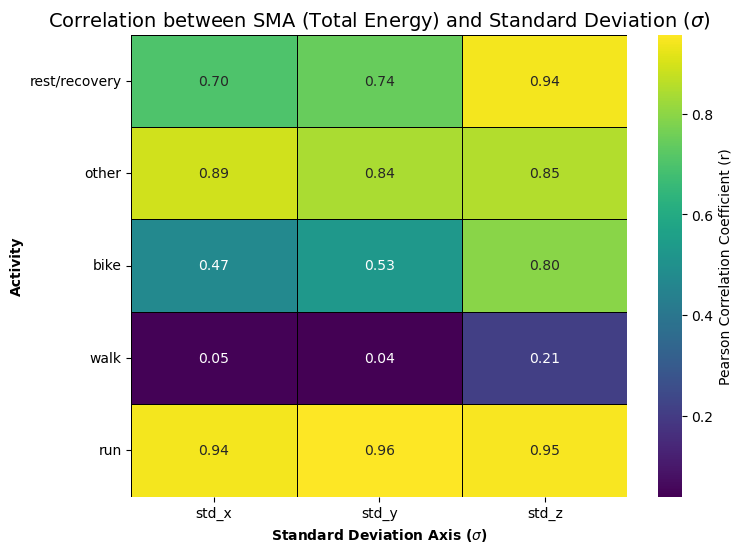

In [57]:
# Correlation Matrix between SMA and STD
# As I plan to use both the std of each axis as well as the SMA feature in my model, I want to ensure they are complenentary and not highly correlated.

features_df = pd.merge(std_features, sma_features, on=['time_window', 'activity'])

# Prepare the list of columns to correlate with SMA
std_cols = ['std_x', 'std_y', 'std_z']

# Calculate correlation for each activity group
correlation_data = {}
for activity in features_df['activity'].unique():
    subset = features_df[features_df['activity'] == activity]
    
    # Calculate correlation between SMA and each STD column
    correlations = subset[std_cols].apply(lambda x: x.corr(subset['sma_mg']))
    
    # Store the results in the dictionary
    correlation_data[activity] = correlations.to_dict()

# Convert the dictionary to a DataFrame for the heatmap
corr_df = pd.DataFrame(correlation_data).T

# Order the rows/activities for better visualization
activity_order = ['rest/recovery', 'other', 'bike', 'walk', 'run']
corr_df = corr_df.reindex(activity_order)


# Visualization: Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis', 
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'},
    linewidths=.5, 
    linecolor='black'
)
plt.title('Correlation between SMA (Total Energy) and Standard Deviation ($\sigma$)', fontsize=14)
plt.xlabel('Standard Deviation Axis ($\sigma$)', fontweight='bold')
plt.ylabel('Activity', fontweight='bold')
plt.yticks(rotation=0)

# Save the plot
plt.savefig('sma_std_correlation_heatmap.png')
print("sma_std_correlation_heatmap.png")

## <mark>Test your idea(s) on another participant</mark>

Load the data from `user2`, and then run all of your previously defined functions on that user's data.

Please discuss. Do your features generalize? Explore why or why not, and if there are ways to make your ideas more general across users.

In [58]:
data2 = pd.read_parquet(f"{file_path}/user2_accelerometer_data.parquet")
labels2 = pd.read_csv(f"{file_path}/user2_activity_labels.csv")

# Add participant ID to data2 and labels2. This will be important for downstream preprocessing to maintain participant-specific information.
data2['participant_id'] = 'user2'
labels2['participant_id'] = 'user2'

In [59]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193900 entries, 0 to 193899
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   time            193900 non-null  float64
 1   x_accel_mg      193900 non-null  int64  
 2   y_accel_mg      193900 non-null  int64  
 3   z_accel_mg      193900 non-null  int64  
 4   participant_id  193900 non-null  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 7.4+ MB


In [60]:
labels2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              13 non-null     object 
 1   time_start      13 non-null     float64
 2   time_end        13 non-null     float64
 3   participant_id  13 non-null     object 
dtypes: float64(2), object(2)
memory usage: 548.0+ bytes


In [61]:
# To ensure the functions to create the features and graphs above generalize, I have created a DataPreprocessing class that can be used to consistently preprocess the data. 
# I've also included the ability and a check to ensure that data from multiple participants can be processed.

class DataPreprocessing:
    def __init__(self, data: pd.DataFrame, labels: pd.DataFrame):

        if  'participant_id' not in data.columns or 'participant_id' not in labels.columns:
            raise ValueError("Participant ID is required for data preprocessing and modeling.")
        self.data = data
        self.labels = labels
        self.merged_data = None
        self.feature_data = None

    def merge_data(self) -> pd.DataFrame:
        # sort the data
        self.data.sort_values('time', inplace=True)
        self.labels.sort_values('time_start', inplace=True)

        logging.info("Data and labels sorted by time.")
        
        # Merge based on 'time' between start time and end time
        self.merged_data = pd.merge_asof(self.data, self.labels, left_on=['time'], right_on=['time_start'], by=['participant_id'], direction='forward')

        logging.info(f"Data merged based on time between start time and end time. size merged data: {self.merged_data.shape} vs size of data: {self.data.shape} and labels: {self.labels.shape}")
        
        # Filter results to only keep matches where time < time_end
        self.merged_data = self.merged_data[self.merged_data['time'] < self.merged_data['time_end']]
        logging.info(f"Merged data filtered to keep only matches where time < time_end. size filtered data: {self.merged_data.shape}")
        
    def add_indicator_variables(self, window_sec: int = 10) -> pd.DataFrame:
        logging.info("Adding indicator variables: 10 sec default time_window and activity.")
        # Calculate start epoch time of 10 sec window
        self.merged_data['window_start_epoch'] = np.floor(self.merged_data['time'] / window_sec) * window_sec
        # Convert window's start epoch time back to datetime
        self.merged_data['time_window'] = pd.to_datetime(self.merged_data['window_start_epoch'], unit='s')
        # Drop intermediate epoch column
        self.merged_data.drop(columns=['window_start_epoch'], inplace=True)

        # Create Activity group
        conditions = [
        self.merged_data['id'].str.contains('rest', case=False, na=False) |
        self.merged_data['id'].str.contains('recovery', case=False, na=False),
        # these will only run if they are not flagged as rest/recovery
        self.merged_data['id'].str.contains('bike', case=False, na=False),
        self.merged_data['id'].str.contains('run', case=False, na=False),
        self.merged_data['id'].str.contains('walk', case=False, na=False),
        ]

        choices = [
        'rest/recovery',
        'bike',
        'run',
        'walk',
        ]

        self.merged_data['activity'] = np.select(condlist=conditions, choicelist=choices, default='other')
    
    def engineer_features(self) -> pd.DataFrame:
        
        self.merged_data['abs_sum'] = self.merged_data[['x_accel_mg', 'y_accel_mg', 'z_accel_mg']].abs().sum(axis=1)
        
        self.feature_data = self.merged_data.groupby(['participant_id', 'activity','time_window']).agg(std_x=('x_accel_mg', 'std'),
                                 std_y=('y_accel_mg', 'std'),
                                 std_z=('z_accel_mg', 'std'),
                                 sma_mg=('abs_sum', 'mean')
                                 )

        self.feature_data.reset_index(inplace=True)

    def run_preprocessing_pipeline(self) -> pd.DataFrame:
        self.merge_data()

        # If merge fails end the pipeline
        if self.merged_data is None:
            return None
        
        self.add_indicator_variables()
        self.engineer_features()

        return self.feature_data

In [62]:
data_prep = DataPreprocessing(data2, labels2)

# This is the final data where the engineered features will be used to predict the the output (i.e. activity) per time window per participant (i.e. id)
data_prep.run_preprocessing_pipeline()

INFO:root:Data and labels sorted by time.
INFO:root:Data merged based on time between start time and end time. size merged data: (193900, 8) vs size of data: (193900, 5) and labels: (13, 4)
INFO:root:Merged data filtered to keep only matches where time < time_end. size filtered data: (176447, 8)
INFO:root:Adding indicator variables: 10 sec default time_window and activity.


,participant_id,activity,time_window,std_x,std_y,std_z,sma_mg
0,user2,bike,2023-04-05 17:09:30,46.785471,46.316122,70.357232,1454.815603
1,user2,bike,2023-04-05 17:09:40,148.679482,158.404864,203.141937,1538.132000
2,user2,bike,2023-04-05 17:09:50,151.702124,118.961053,120.908785,1542.066000
3,user2,bike,2023-04-05 17:10:00,158.726614,203.749338,228.447643,1515.878000
4,user2,bike,2023-04-05 17:10:10,155.761287,154.145903,176.016508,1606.588000
...,...,...,...,...,...,...,...
354,user2,walk,2023-04-05 17:57:10,152.955072,143.691660,151.803759,1628.930000
355,user2,walk,2023-04-05 17:57:20,157.679182,146.113160,138.398088,1614.836000
356,user2,walk,2023-04-05 17:57:30,158.974848,145.171328,141.864696,1593.834000
357,user2,walk,2023-04-05 17:57:40,206.850203,215.609699,356.078620,1478.592000


In [63]:
# This is the ouput of the original function for final1
final1

,time,x_accel_mg,y_accel_mg,z_accel_mg,id,time_start,time_end,time_window,activity,abs_sum
0,1.680644e+09,843,-204,390,lying_down_rest_5_min,1.680644e+09,1.680645e+09,2023-04-04 21:27:50,rest/recovery,1437
1,1.680644e+09,859,-172,449,lying_down_rest_5_min,1.680644e+09,1.680645e+09,2023-04-04 21:27:50,rest/recovery,1480
2,1.680644e+09,843,-188,449,lying_down_rest_5_min,1.680644e+09,1.680645e+09,2023-04-04 21:27:50,rest/recovery,1480
3,1.680644e+09,843,-188,425,lying_down_rest_5_min,1.680644e+09,1.680645e+09,2023-04-04 21:27:50,rest/recovery,1456
4,1.680644e+09,875,-188,433,lying_down_rest_5_min,1.680644e+09,1.680645e+09,2023-04-04 21:27:50,rest/recovery,1496
...,...,...,...,...,...,...,...,...,...,...
190256,1.680647e+09,250,828,-668,sitting_recovery_post_run_5_min,1.680647e+09,1.680648e+09,2023-04-04 22:31:20,rest/recovery,1746
190257,1.680647e+09,218,890,-559,sitting_recovery_post_run_5_min,1.680647e+09,1.680648e+09,2023-04-04 22:31:20,rest/recovery,1667
190258,1.680647e+09,171,843,-586,sitting_recovery_post_run_5_min,1.680647e+09,1.680648e+09,2023-04-04 22:31:20,rest/recovery,1600
190259,1.680647e+09,0,984,-16,sitting_recovery_post_run_5_min,1.680647e+09,1.680648e+09,2023-04-04 22:31:20,rest/recovery,1000


In [64]:
# final2 is created in the same manner as final1, but used the DataPreprocessing class. 
# It also includes participant_id handling for future multi-participant modeling.
# It also includes abs_sum as this is calculated in the engineer_features method.

final2 = data_prep.merged_data
final2

,time,x_accel_mg,y_accel_mg,z_accel_mg,participant_id,id,time_start,time_end,time_window,activity,abs_sum
0,1.680714e+09,718,78,621,user2,lying_down_rest_5_min,1.680714e+09,1.680715e+09,2023-04-05 17:03:30,rest/recovery,1417
1,1.680714e+09,718,78,601,user2,lying_down_rest_5_min,1.680714e+09,1.680715e+09,2023-04-05 17:03:30,rest/recovery,1397
2,1.680714e+09,734,78,578,user2,lying_down_rest_5_min,1.680714e+09,1.680715e+09,2023-04-05 17:03:30,rest/recovery,1390
3,1.680714e+09,750,93,578,user2,lying_down_rest_5_min,1.680714e+09,1.680715e+09,2023-04-05 17:03:30,rest/recovery,1421
4,1.680714e+09,718,93,585,user2,lying_down_rest_5_min,1.680714e+09,1.680715e+09,2023-04-05 17:03:30,rest/recovery,1396
...,...,...,...,...,...,...,...,...,...,...,...
176442,1.680718e+09,500,656,-520,user2,sitting_recovery_post_walk_5_min,1.680718e+09,1.680718e+09,2023-04-05 18:02:10,rest/recovery,1676
176443,1.680718e+09,515,656,-508,user2,sitting_recovery_post_walk_5_min,1.680718e+09,1.680718e+09,2023-04-05 18:02:10,rest/recovery,1679
176444,1.680718e+09,500,656,-520,user2,sitting_recovery_post_walk_5_min,1.680718e+09,1.680718e+09,2023-04-05 18:02:10,rest/recovery,1676
176445,1.680718e+09,453,671,-536,user2,sitting_recovery_post_walk_5_min,1.680718e+09,1.680718e+09,2023-04-05 18:02:10,rest/recovery,1660


INFO:root:activity_snippets_plot.png


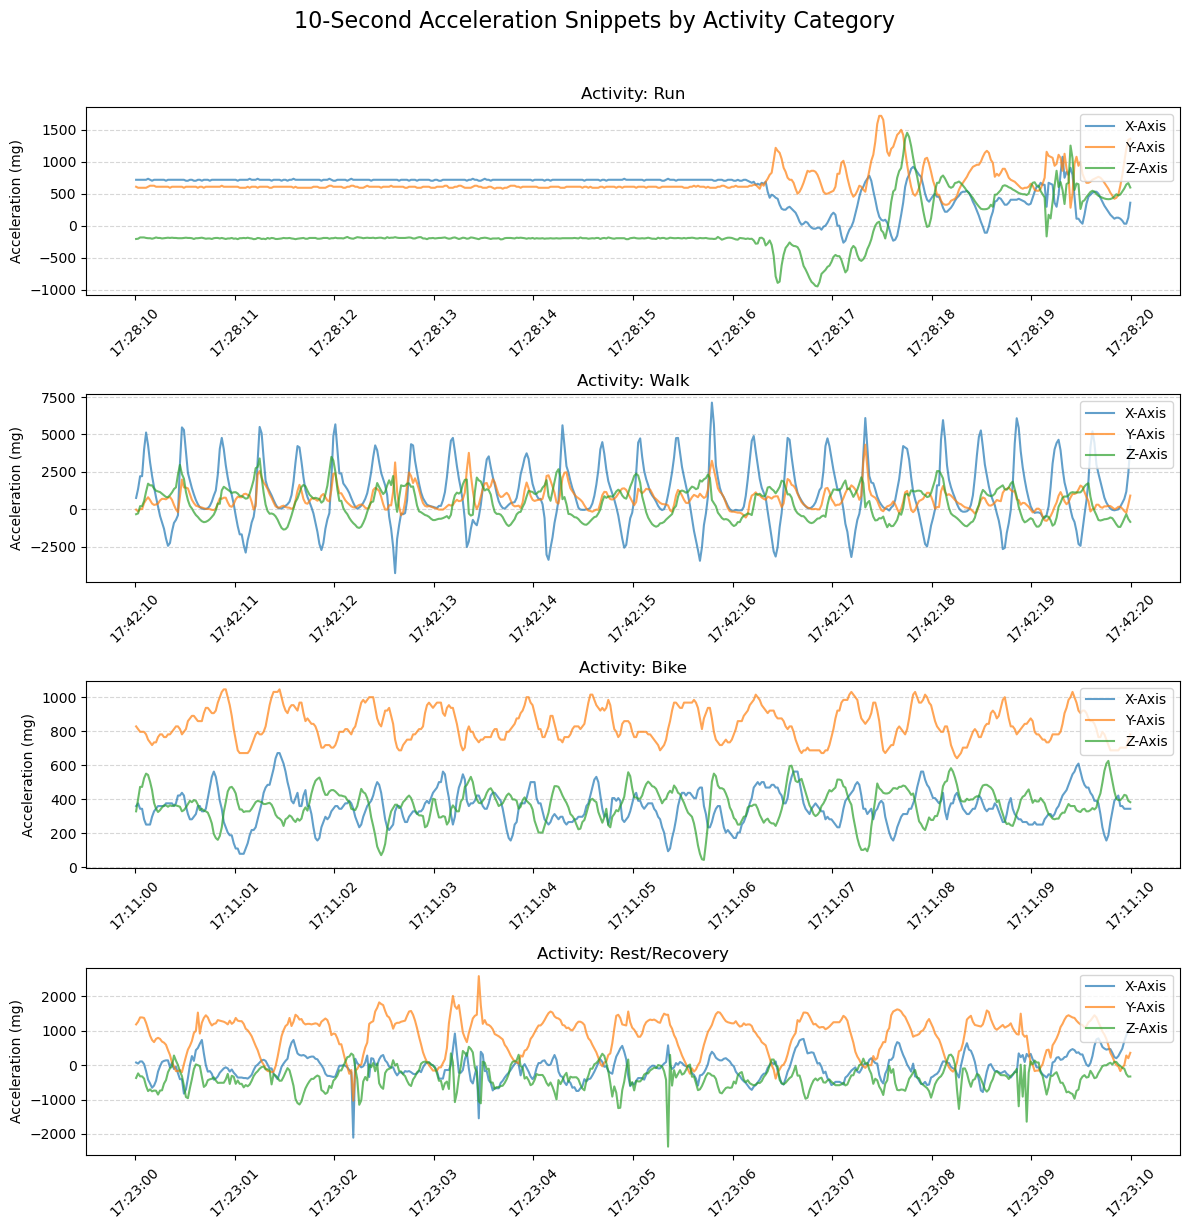

In [65]:
# ability to plot activity data for final2 to ensure it works as expected
plot_activity_data(final2, window_index=9)

INFO:root:Data and labels sorted by time.
INFO:root:Data merged based on time between start time and end time. size merged data: (193900, 8) vs size of data: (193900, 5) and labels: (13, 4)
INFO:root:Merged data filtered to keep only matches where time < time_end. size filtered data: (176447, 8)
INFO:root:Adding indicator variables: 10 sec default time_window and activity.
INFO:root:std_dev_over_time_by_axis_plot.png


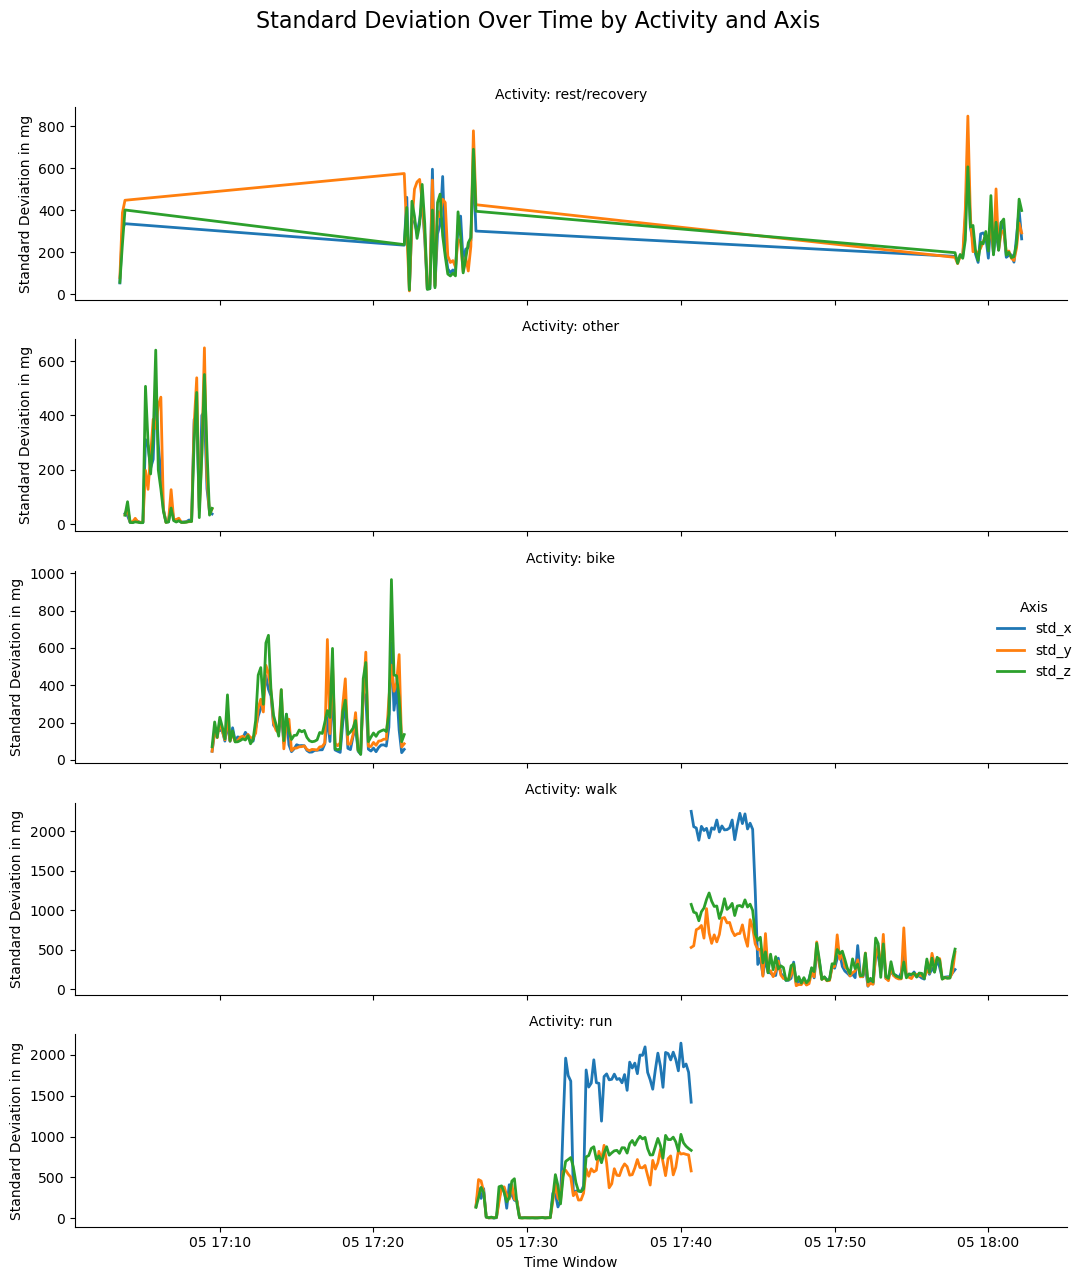

In [66]:
# Showing ability to plot STD timeseries data derived from data2 and labels2 to ensure it works as expected

std_features_melt2 = data_prep.run_preprocessing_pipeline().melt(
    id_vars=['time_window', 'activity'], 
    value_vars=['std_x', 'std_y', 'std_z'],
    var_name='Axis',
    value_name='Standard Deviation in mg'
)

plot_activity_timeseries(std_features_melt2,
                       y_feature='Standard Deviation in mg',
                       y_axis_label='Standard Deviation in mg', 
                       title='Standard Deviation Over Time by Activity and Axis', 
                       savefig_name='std_dev_over_time_by_axis_plot.png',
                       hue='Axis'
                       )

INFO:root:Data and labels sorted by time.


INFO:root:Data merged based on time between start time and end time. size merged data: (193900, 8) vs size of data: (193900, 5) and labels: (13, 4)
INFO:root:Merged data filtered to keep only matches where time < time_end. size filtered data: (176447, 8)
INFO:root:Adding indicator variables: 10 sec default time_window and activity.
INFO:root:sma_over_time_plot.png


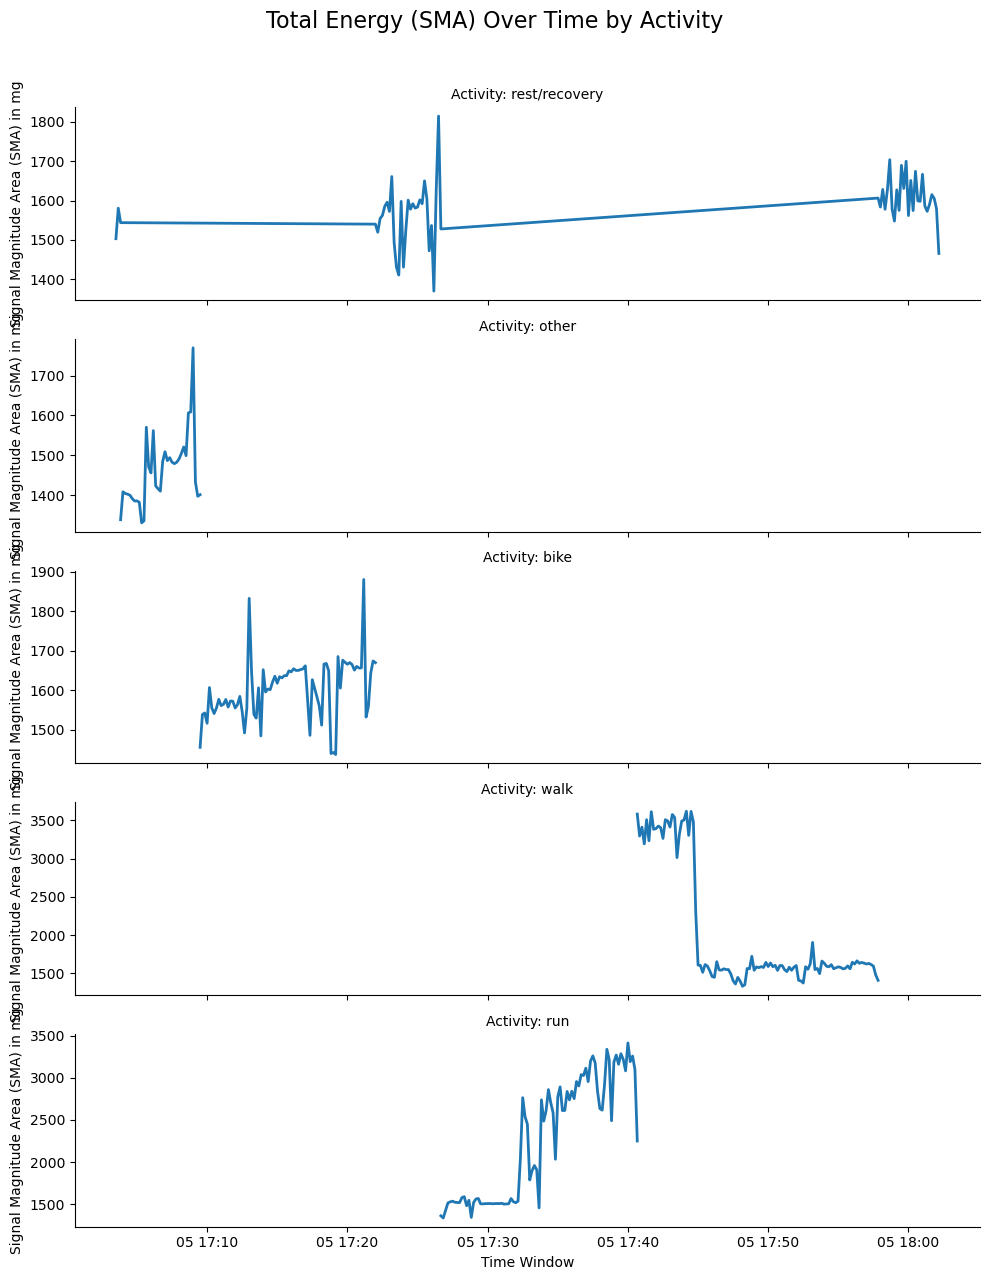

In [67]:
# Showing ability to plot SMA timeseries data derived from data2 and labels2 to ensure it works as expected

sma_features2 = data_prep.run_preprocessing_pipeline()[['activity', 'time_window', 'sma_mg']]
plot_activity_timeseries(sma_features2,
                       y_feature='sma_mg',
                       y_axis_label='Signal Magnitude Area (SMA) in mg', 
                       title='Total Energy (SMA) Over Time by Activity', 
                       savefig_name='sma_over_time_plot.png',
                       )

# <mark>Problem 3 - Prediction model</mark>

Assume that you have a larger version of this dataset with many more users. 

Discuss how you might build a supervised machine learning model that could automatically recognize the activities of any user wearing this accelerometer device. 

Discuss how you would formulate the ML problem. Discuss how you would construct the training set. What inputs and outputs would you choose for the ML model? What types of methods would you consider? What assumptions are you making? Etc.

In [ ]:
# DATA CLEANING STRATEGY #

# I would first off want to create a cleaning script that removes any time windows that contain transition periods or stillness within active periods.
# This could be done by setting thresholds for std and sma features per activity group and removing any time windows that fall outside these thresholds.
# I would also want to ensure that any labeling errors are corrected, possibly by cross-referencing with additional data sources if available.
# This would ensure that the model is trained on high-quality, representative data.

# MODELING STRATEGY #

# ML Problem Formulation:
# This is a multi-class classification problem where the goal is to predict the activity label (i.e. y) per time window per participant (i.e. id) 
# based on the engineered features (e.g. std and sma) (i.e. X).
# I would prioritize the F1-Score (harmonic mean of Precision and Recall) or Balanced Accuracy.
# This ensures the model performs well across all activities, especially those that might be less frequent. 

# Training Set Construction:
# The dataset must include a large diverse set of users to generalize well to unseen data.

# Cross-Validation Strategy:
# I would use Grouped K-Fold Cross-Validation splitting the data such that all time windows belonging to a single user are kept entirely in either the training set 
# or the testing set.
# This prevents data leakage and ensures the model is evaluated on truly unseen users.

# Feature Inputs:
# The input features would include the engineered features: std_x, std_y, std_z, and sma_mg to caputre both variability and total energy of movement.
# I would also consider adding:
# mean and median of x,y,z to measure signal bias and baseline posture.
# range (max-min) of x,y,z to capture peak magnitude.

# Model Selection:
# I would start with basic machine learning classifiers using the feature inputs described above
# Decision trees, random forests, gradient boosting machines (GBMs) are excellent for non-linear, high-dimensional data, and can handle multi-class classification well. 
# They require careful hyperparameter tuning to avoid overfitting.
# Support vector machines (SVMs) is also an option as they find optimal boundries in high-dimensional space, but require feature scaling. 
# These models are interpretable and can provide insights into feature importance or permutation importance.
# If the performance is not satisfactory, I would consider more complex models like CNN/LSTM.

# What I am not sure of is how to handle the position of the device on the body. 
# I am curiousm, do we have data to measure if position significantly impacts the accelerometer readings? 
# If so, I would need to consider this in my modeling strategy, possibly by including device position as an additional feature if available.

# Example of how I have build a multiclass model in the past. It is not perfectly aligned with this challenge, but classes ModelBuild and ModelQA show my general approach:
# In this notebook I predict Low, Medium and High engagement levels of online gamers based on their in-game activity logs using LR and GBC. 
# https://github.com/AuroraLeport/IndependentProjects/blob/main/Kaggle_Projects/Kaggle_Predict_Online_Gaming_Behavior.ipynb

Now consider in particular that there may be deployment constraints on the wearable device, such as memory, computational power, rate of data transfer, and battery life. However, there are more computational resources available once data is transferred from the device to the mobile phone or cloud.

How does this change or constrain your initial approach?

In [ ]:
# The cost of implementing the model in a real-world setting, will be the feature engineering and classification steps, 
# not the data collection step, as accelerometer data is continuously collected by the Oura Ring.
# Since the device itself does not have a display, the model can run entirely on the connected smartphone or cloud server, which as stated has more coputational resources.